In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw5.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 5: Putting it all together 
### Associated lectures: All material till lecture 13 

<div class="alert-warning">
    
## Instructions  
rubric={points}

You will earn points for following these instructions and successfully submitting your work on Gradescope.  

### Before you start  

- Please **read carefully
[Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2025W2/syllabus#use-of-generative-ai-in-the-course)** before starting the homework assignment. 
  
- Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions) for detailed guidance on completing and submitting assignments. 

### Group work instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2.
  
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
- If you would like to use late tokens for the homework, all group members must have the necessary late tokens available. Please note that the late tokens will be counted for all members of the group.   
### Before submitting  

- **Run all cells** (▶▶ button) to ensure the notebook executes cleanly from top to bottom.

  - Execution counts must start at **1** and be sequential.
    
  - Notebooks with missing outputs or errors may lose marks.

- **Do not upload or push data files** used in this lab to GitHub or Gradescope. (A `.gitignore` is provided to prevent this.)  


### Submitting on Gradescope  

- Upload **only** your `.ipynb` file (with outputs shown) and any required output files. Do **not** submit extra files.
  
- If needed, refer to the [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/).  
- If your notebook is too large to render, also upload a **Web PDF** or **HTML** version.  
  - You can create one using **File $\rightarrow$ Save and Export Notebook As**.  
  - If you get an error when creating a PDF, try running the following commands in your lab directory:  

    ```bash
    conda install -c conda-forge nbconvert-playwright
    jupyter nbconvert --to webpdf lab1.ipynb
    ```  

  - Ensure all outputs are visible in your PDF or HTML file; TAs cannot grade your work if outputs are missing.

</div>


_Note: Unlike previous assignments, this one is open-ended and project-style. Treat it as an opportunity to explore, experiment, and learn._

<!-- BEGIN QUESTION -->

## Imports

<div class="alert alert-warning">
    
Imports
    
</div>

_Points:_ 0

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_validate
from sklearn.metrics import recall_score

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

from sklearn.feature_selection import RFECV

import shap

shap.initjs()
warnings.filterwarnings('ignore')

/Users/elainetao/miniforge3/envs/analysis_env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<!-- END QUESTION -->

## Introduction

In this homework you will be working on an open-ended mini-project, where you will put all the different things you have learned so far together to solve an interesting problem.

A few notes and tips when you work on this mini-project: 

#### Tips
1. This mini-project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.


#### A final note
Finally, this style of this "project" question is different from other assignments. It'll be up to you to decide when you're "done" -- in fact, this is one of the hardest parts of real projects. But please don't spend WAY too much time on this... perhaps "a few hours" (10-14 hours???) is a good guideline for this project . Of course if you're having fun you're welcome to spend as much time as you want! But, if so, try not to do it out of perfectionism or getting the best possible grade. Do it because you're learning and enjoying it. Students from the past cohorts have found such kind of labs useful and fun and I hope you enjoy it as well. 

<br><br>

<!-- BEGIN QUESTION -->

## 1. Pick your problem and explain the prediction problem
<hr>
rubric={points:3}

In this mini project, you have the option to choose on which dataset you will be working on. The tasks you will need to carry on will be similar, independently of your choice.

### Option 1
You can choose to work on a classification problem of predicting whether a credit card client will default or not. 
For this problem, you will use [Default of Credit Card Clients Dataset](https://www.kaggle.com/uciml/default-of-credit-card-clients-dataset). In this data set, there are 30,000 examples and 24 features, and the goal is to estimate whether a person will default (fail to pay) their credit card bills; this column is labeled "default.payment.next.month" in the data. The rest of the columns can be used as features. You may take some ideas and compare your results with [the associated research paper](https://www.sciencedirect.com/science/article/pii/S0957417407006719), which is available through [the UBC library](https://www.library.ubc.ca/). 


### Option 2
You can choose to work on a regression problem using a [dataset](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data) of New York City Airbnb listings from 2019. As usual, you'll need to start by downloading the dataset, then you will try to predict `reviews_per_month`, as a proxy for the popularity of the listing. Airbnb could use this sort of model to predict how popular future listings might be before they are posted, perhaps to help guide hosts create more appealing listings. In reality they might instead use something like vacancy rate or average rating as their target, but we do not have that available here.

> Note there is an updated version of this dataset with more features available [here](http://insideairbnb.com/). The features were are using in `listings.csv.gz` for the New York city datasets. You will also see some other files like `reviews.csv.gz`. For your own interest you may want to explore the expanded dataset and try your analysis there. However, please submit your results on the dataset obtained from Kaggle.


<div class="alert alert-info">
    
**Your tasks:**

1. Review the available datasets and choose the one you find most interesting. It may help to read through the dataset documentation on Kaggle before deciding.
2. Once you've selected a dataset, take time to understand the problem it represents and the meaning of each feature. Use the Kaggle documentation to guide you.
3. Download the dataset and load it into a pandas DataFrame.
4. Write a few sentences summarizing your initial thoughts about the problem and the dataset.
   
</div>

<div class="alert alert-warning">
    
Solution_1
    
</div>

_Points:_ 3

A few thoughts I've had about the problem are that I think whether a customer pays in a timely manner will have a large impact on their default status. If a customer tends to provide late payments, they will probably default. Lifestyle in my opinion probably has less of an impact, although I'd expect older, married, and and well-educated folks to be less likely to default.

Taking a general overview of the dataset, I can see that there are a lot of numeric columns, and columns that look numeric but are actually categorical. `EDUCATION` and the `PAY` columns stand out to me as what should be ordinal columns, based off their documentation. There also appears to be some data that hasn't been listed by the documentation, such as the -2 value in the PAY columns. I can tell I'll need to do quite a bit of preprocessing for the categorical values, especially with the columns with a lack of information from the documentation.

**Additional information for the unlisted data is taken from: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset/discussion/34608**

In [2]:
credit_card = pd.read_csv("../data/UCI_Credit_card.csv")
credit_card.head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
5,6,50000.0,1,1,2,37,0,0,0,0,...,19394.0,19619.0,20024.0,2500.0,1815.0,657.0,1000.0,1000.0,800.0,0
6,7,500000.0,1,1,2,29,0,0,0,0,...,542653.0,483003.0,473944.0,55000.0,40000.0,38000.0,20239.0,13750.0,13770.0,0
7,8,100000.0,2,2,2,23,0,-1,-1,0,...,221.0,-159.0,567.0,380.0,601.0,0.0,581.0,1687.0,1542.0,0
8,9,140000.0,2,3,1,28,0,0,2,0,...,12211.0,11793.0,3719.0,3329.0,0.0,432.0,1000.0,1000.0,1000.0,0
9,10,20000.0,1,3,2,35,-2,-2,-2,-2,...,0.0,13007.0,13912.0,0.0,0.0,0.0,13007.0,1122.0,0.0,0


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. Split the data into train (70%) and test (30%) portions with `random_state=123`.

> If your computer cannot handle training on 70% training data, make the test split bigger.

</div>

<div class="alert alert-warning">
    
Solution_2
    
</div>

_Points:_ 2

In [4]:
X = credit_card.drop(columns = ['default.payment.next.month'])
y = credit_card['default.payment.next.month']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, train_size = 0.7, random_state = 123)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>
rubric={points:10}

<div class="alert alert-info">

**Your tasks:**

1. **Perform exploratory data analysis (EDA)**: Conduct an initial exploration of the training set to better understand its characteristics.

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

</div>

<div class="alert alert-warning">
    
Solution_3
    
</div>

_Points:_ 10

The first, most important summary statistic that I acquired was the proportion of each class in `y_train` since it shows me that I am facing a class imbalance and should not use accuracy as my evaluation metric. Another summary statistic I found helpful in the `.describe()` table was the median (50%) because it provides a better idea of what an average person may be expected to pay or how much they borrow, without being impacted by outliers like the mean would be. `.shape` gives me a good idea that there's actually no missing data in the columns and I won't need to impute the data.

I found the histogram of the `BILL_AMT`, `PAY_AMT`, and `LIMIT_BAL` columns to be helpful in seeing that are there quite a few outliers around the numeric data. It's hard to see in the histogram, but in the `.describe()` table, there are a few data points nearing 1,000,000 and there are also data points that are in the negatives. The bar charts for the categorical counts are also important because it gives me an idea of how to tweak the features. For example, the `MARRIAGE` column has a few points under 0, but there is no indication on what 0 represents. I will eventually change the 0 to fall under class 3 (other).

Overall, I see that the numeric data is primarily left-skewed. Most data points fall within 0 - 20,000, while `AGE` is likely centered closer to 30. The categorical data, besides `SEX`, mostly clusters in a single category (for `PAY`, this means 0), and has less points that are scattered throughout the rest of the categories. And in terms of the labels, there is a decently-sized class imbalance that favors non-defaulters. These will be important when deciding which models to use, because some models respond quite badly to outliers, like KNN.

The best metric for my situation would be to use recall. False negatives are very important because the lender is primarily concerned about defaulting credit payments, and accidentally labeling someone as a non-defaulter when they actually default would be worse than labeling someone as a defaulter when they do pay on time. Using accuracy is not a good option for me since at the minimum a dummy classifier could score around 0.75 and each subsequent model would not look like it's improving much at all. At least with recall I can see if a model has improved compared to the baseline. From this point on, all my scores will be recall.

In [5]:
X_train.shape

(21000, 24)

In [6]:
#Rotated so I can verify all columns have no missing values.

X_train.describe().round(4).T

,count,mean,std,min,25%,50%,75%,max
ID,21000.0,14962.3482,8650.7340,1.0,7498.75,14960.5,22458.25,30000.0
LIMIT_BAL,21000.0,167880.6514,130202.6822,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,21000.0,1.6008,0.4898,1.0,1.00,2.0,2.00,2.0
EDUCATION,21000.0,1.8521,0.7930,0.0,1.00,2.0,2.00,6.0
MARRIAGE,21000.0,1.5540,0.5217,0.0,1.00,2.0,2.00,3.0
AGE,21000.0,35.5008,9.2126,21.0,28.00,34.0,41.00,79.0
PAY_0,21000.0,-0.0154,1.1205,-2.0,-1.00,0.0,0.00,8.0
PAY_2,21000.0,-0.1371,1.1945,-2.0,-1.00,0.0,0.00,8.0
PAY_3,21000.0,-0.1716,1.1961,-2.0,-1.00,0.0,0.00,8.0
PAY_4,21000.0,-0.2252,1.1686,-2.0,-1.00,0.0,0.00,8.0


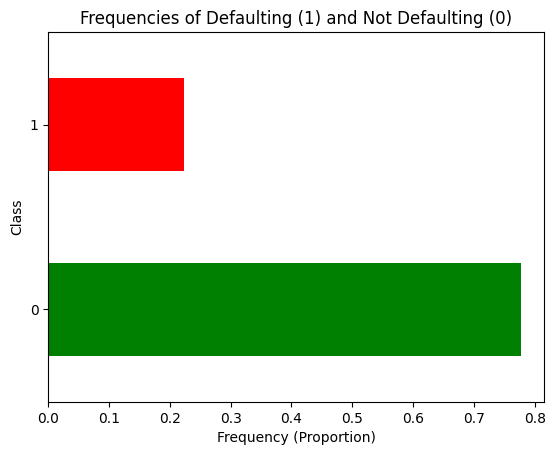

In [7]:
(y_train.value_counts(normalize = True, sort = False)).plot.barh(color = ['green', 'red'])
plt.title("Frequencies of Defaulting (1) and Not Defaulting (0)")
plt.xlabel("Frequency (Proportion)")
plt.ylabel("Class")
plt.show()

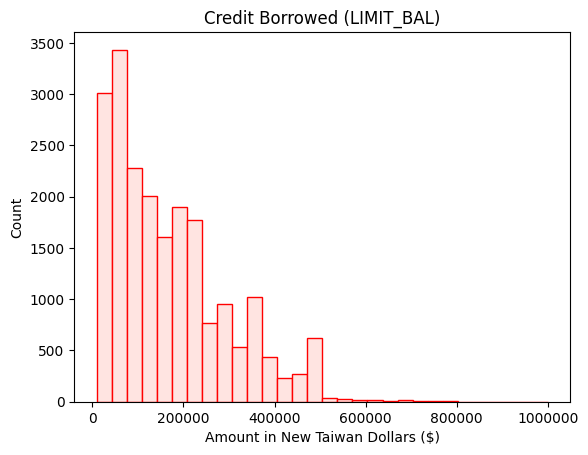

In [8]:
X_train['LIMIT_BAL'].hist(bins = 30, edgecolor = 'red', color = 'mistyrose')
plt.grid(None)
plt.ticklabel_format(style = 'plain')
plt.title("Credit Borrowed (LIMIT_BAL)")
plt.xlabel("Amount in New Taiwan Dollars ($)")
plt.ylabel("Count")
plt.show()

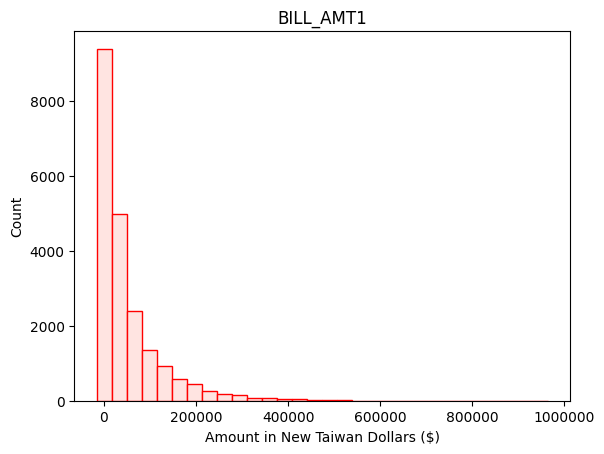

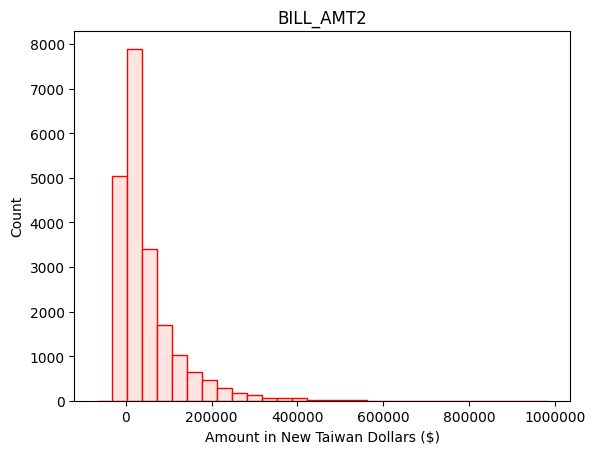

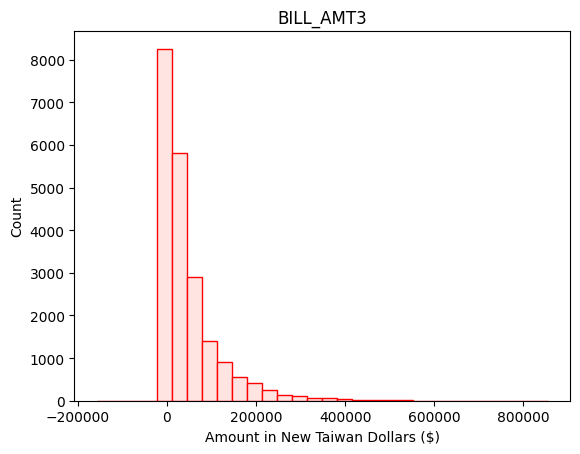

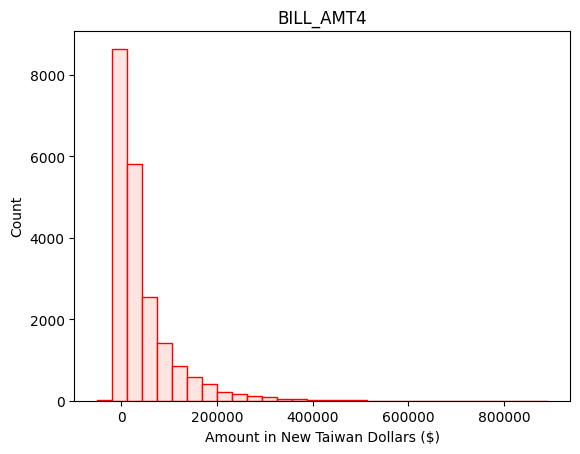

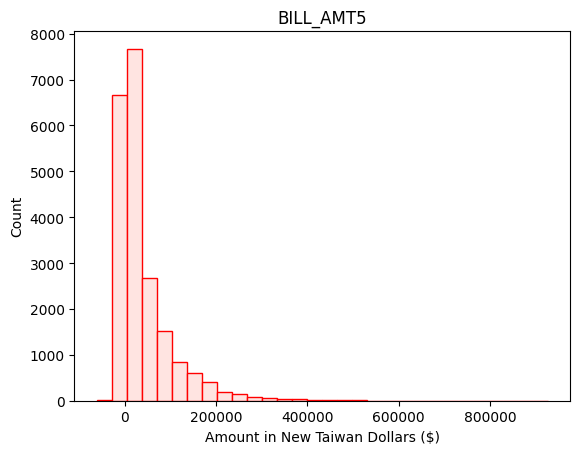

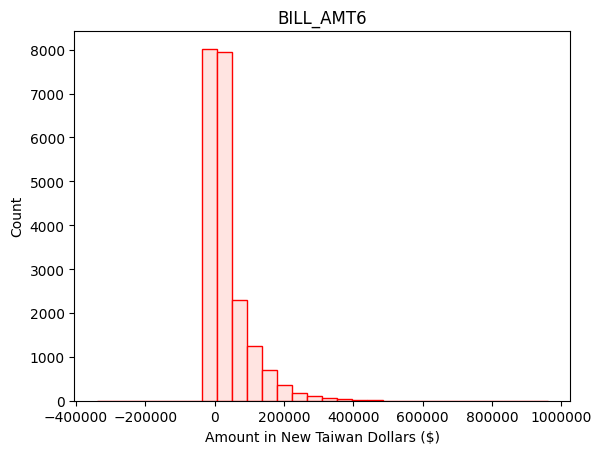

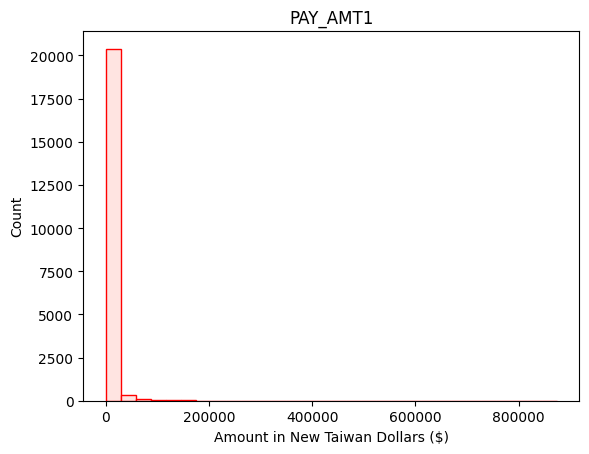

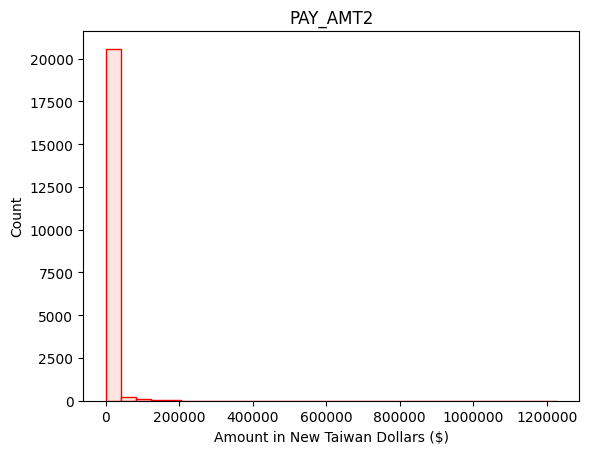

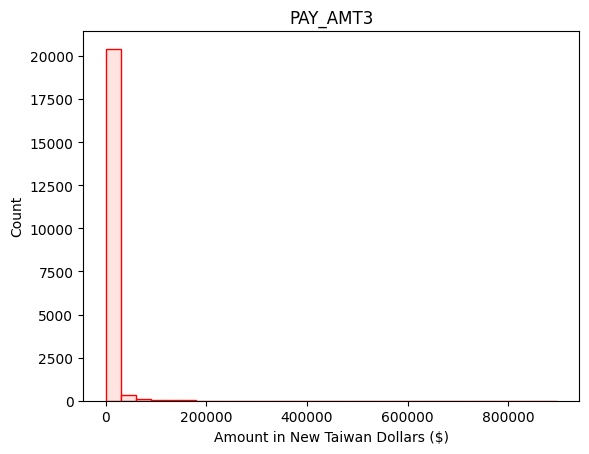

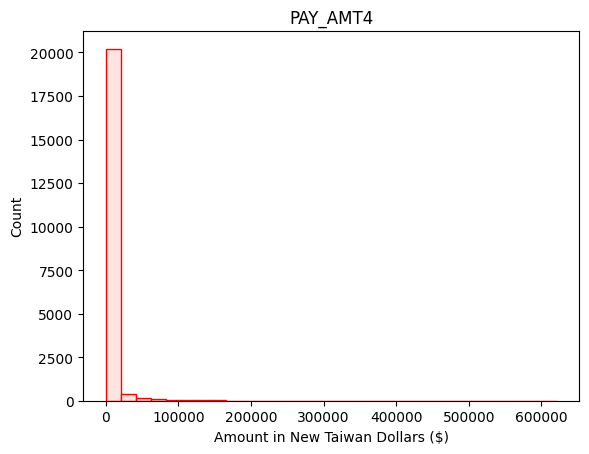

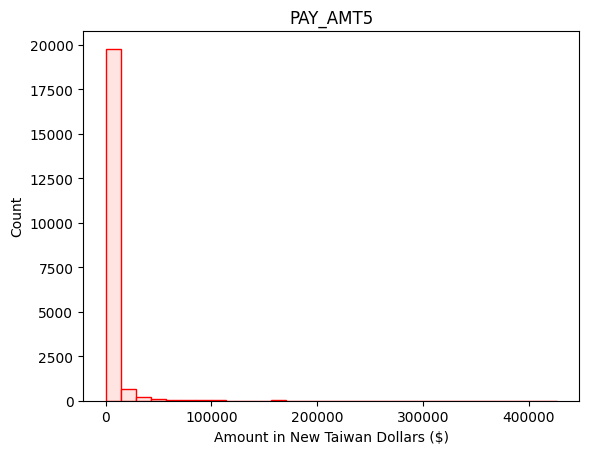

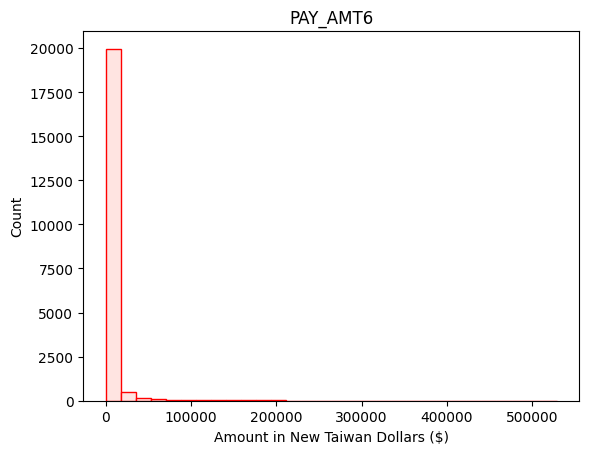

In [9]:
payments = ['BILL_AMT', 'PAY_AMT']

for item in payments:
    for num in range(1, 7):
        X_train[[item + str(num)]].hist(bins = 30, edgecolor = 'red', color = 'mistyrose')
        plt.grid(None)
        plt.ticklabel_format(style = 'plain')
        plt.title(item + str(num))
        plt.ylabel("Count")
        plt.xlabel("Amount in New Taiwan Dollars ($)")
        plt.show()

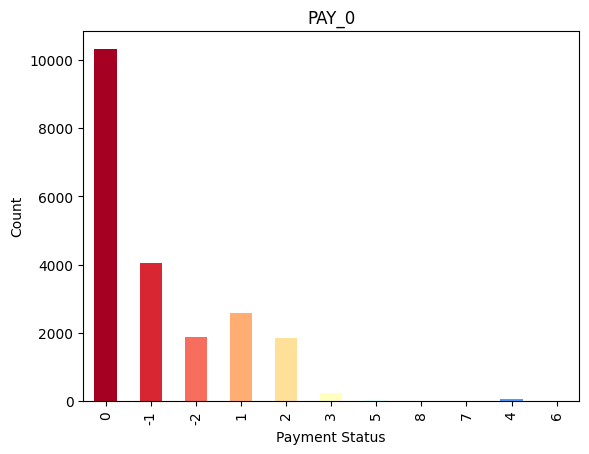

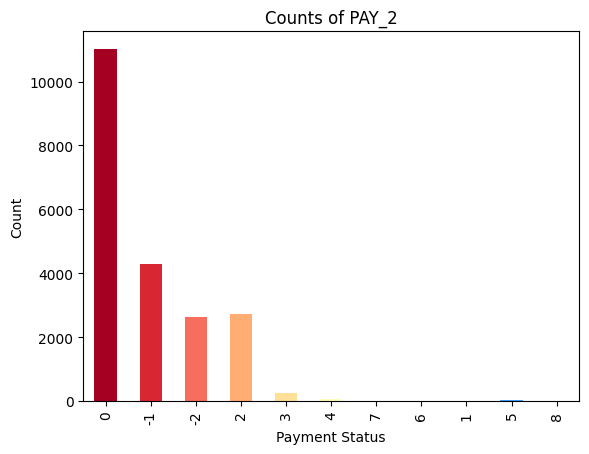

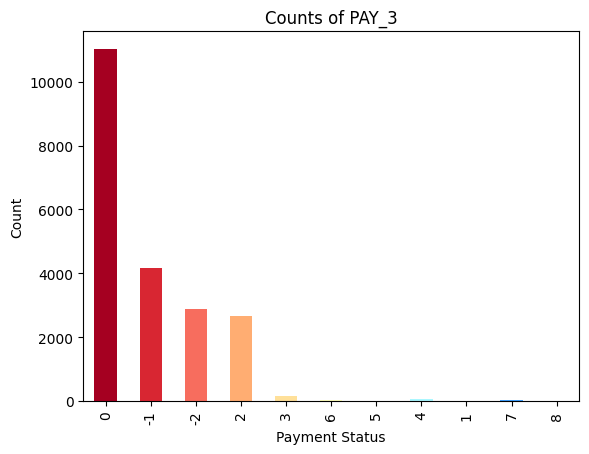

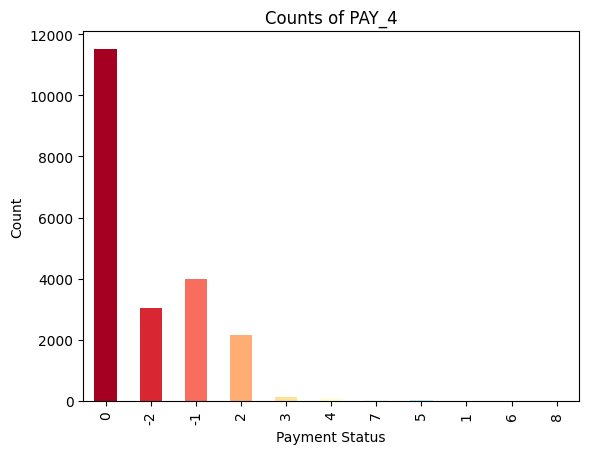

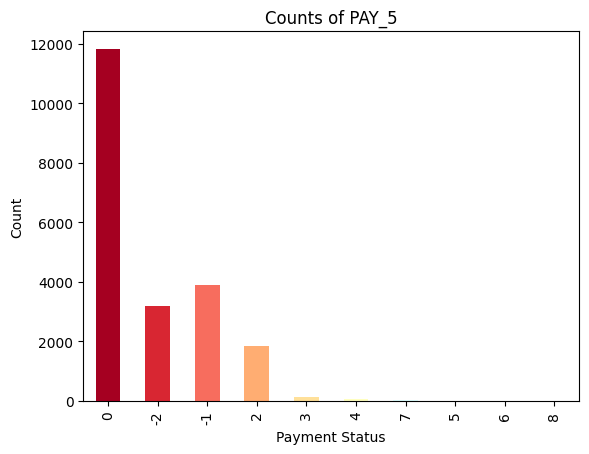

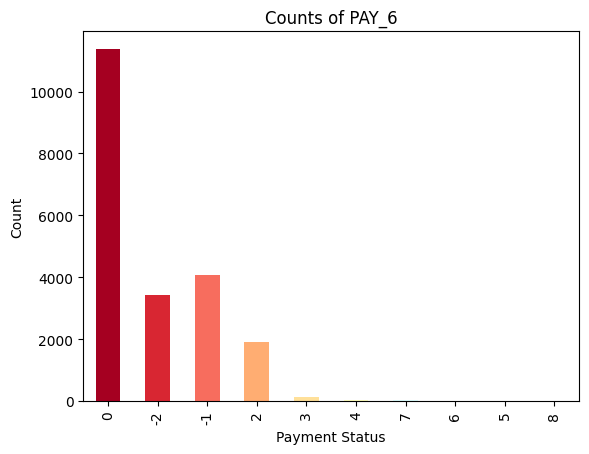

In [10]:
fill_colors = ['#A50021', '#D82632', '#F76D5E', '#FFAD72',
               '#FFE099', '#FFFFBF', '#E0FFFF', '#AAF7FF',
               '#72D8FF', '#3FA0FF', '#264CFF']

(X_train['PAY_0'].value_counts(sort = False)).plot.bar(color = fill_colors)
plt.title('PAY_0')
plt.ylabel("Count")
plt.xlabel("Payment Status")
plt.show()

for i in range(2, 7):
    (X_train['PAY_' + str(i)].value_counts(sort = False)).plot.bar(color = fill_colors)
    plt.title('Counts of PAY_' + str(i))
    plt.ylabel("Count")
    plt.xlabel("Payment Status")
    plt.show()

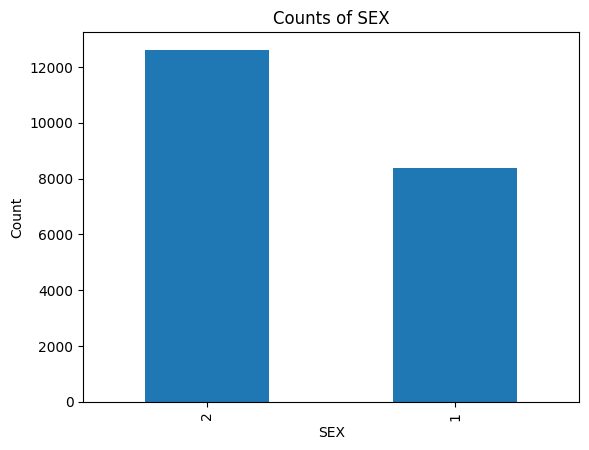

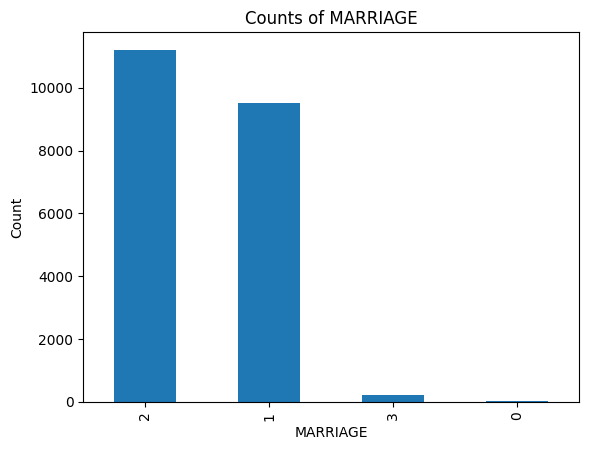

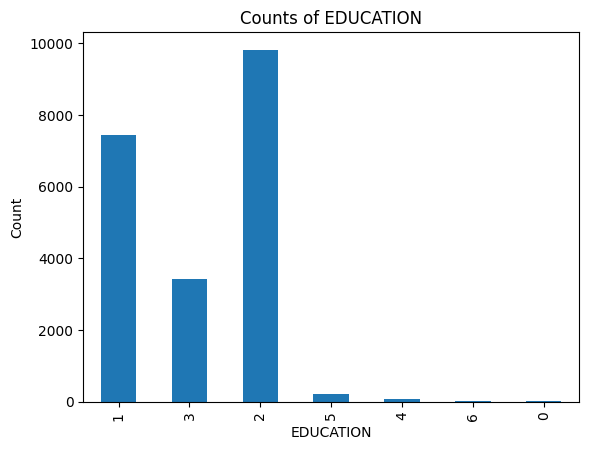

In [11]:
categorical = ['SEX', 'MARRIAGE', 'EDUCATION']

for category in categorical:
    (X_train[category].value_counts(sort = False)).plot.bar()
    plt.title('Counts of ' + category)
    plt.ylabel("Count")
    plt.xlabel(category)
    plt.show()

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
rubric={points:1}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature engineering**: Create new features that are relevant to the problem and use this updated feature set in the following exercises. You may need to iterate between **feature engineering** and **preprocessing** to refine your features and improve model performance.
   
</div>

<div class="alert alert-warning">
    
Solution_4
    
</div>

_Points:_ 1

In [12]:
X_train['SEX'] = X_train['SEX'].replace({1: 0, 2: 1})
X_test['SEX'] = X_test['SEX'].replace({1: 0, 2: 1})

In [13]:
X_train['EDUCATION'] = X_train['EDUCATION'].replace([0, 5, 6], 4)
X_test['EDUCATION'] = X_test['EDUCATION'].replace([0, 5, 6], 4)

In [14]:
X_train['EDUCATION_TEXT'] = X_train['EDUCATION'].replace({1: 'graduate school',
                                                          2: 'university', 3: 'high school', 4: 'other'})
X_test['EDUCATION_TEXT'] = X_test['EDUCATION'].replace({1: 'graduate school',
                                                          2: 'university', 3: 'high school', 4: 'other'})

In [15]:
values_dict = {-2: 'no consumption', -1: 'pay duly', 0: 'minimum payment', 1: '1 month late',
              2: '2 months late', 3: '3 months late', 4: '4 months late', 5: '5 months late',
              6: '6 months late', 7: '7 months late', 8: '8 months late'}

X_train['PAY_0_TEXT'] = X_train['PAY_0'].replace(values_dict)
X_test['PAY_0_TEXT'] = X_test['PAY_0'].replace(values_dict)

for i in range(2, 7):
    X_train['PAY_' + str(i) + '_TEXT'] = X_train['PAY_' + str(i)].replace(values_dict)
    X_test['PAY_' + str(i) + '_TEXT'] = X_test['PAY_' + str(i)].replace(values_dict)

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Identify feature types**: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

2. **Define a column transformer (if needed)**: Implement a `ColumnTransformer` to apply the appropriate preprocessing steps to each feature type.
 
</div>

<div class="alert alert-warning">
    
Solution_5
    
</div>

_Points:_ 10

In [16]:
numerical_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT1',
                      'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
                      'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
                      'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4',
                      'PAY_AMT5', 'PAY_AMT6']
passthrough_features = ['SEX']
categorical_features = ['MARRIAGE']
ordinal_pay_features = ['PAY_0_TEXT', 'PAY_2_TEXT', 'PAY_3_TEXT', 'PAY_4_TEXT', 'PAY_5_TEXT', 'PAY_6_TEXT']
ordinal_education_feature = ['EDUCATION_TEXT']
dropped_features = ['ID', 'EDUCATION', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

In [17]:
pay_order = [['8 months late', '7 months late', '6 months late',
             '5 months late', '4 months late', '3 months late', '2 months late',
             '1 month late', 'minimum payment', 'pay duly', 'no consumption'],
            ['8 months late', '7 months late', '6 months late',
             '5 months late', '4 months late', '3 months late', '2 months late',
             '1 month late', 'minimum payment', 'pay duly', 'no consumption'],
            ['8 months late', '7 months late', '6 months late',
             '5 months late', '4 months late', '3 months late', '2 months late',
             '1 month late', 'minimum payment', 'pay duly', 'no consumption'],
            ['8 months late', '7 months late', '6 months late',
             '5 months late', '4 months late', '3 months late', '2 months late',
             '1 month late', 'minimum payment', 'pay duly', 'no consumption'],
            ['8 months late', '7 months late', '6 months late',
             '5 months late', '4 months late', '3 months late', '2 months late',
             'minimum payment', 'pay duly', 'no consumption'],
            ['8 months late', '7 months late', '6 months late',
             '5 months late', '4 months late', '3 months late', '2 months late',
             'minimum payment', 'pay duly', 'no consumption']]
education_order = ['other', 'high school', 'university', 'graduate school']

numerical_transformer = MinMaxScaler()
categorical_transformer = OneHotEncoder(dtype = int, sparse_output = False)
ordinal_pay_transformer = OrdinalEncoder(categories = pay_order, dtype = int)
ordinal_education_transformer = OrdinalEncoder(categories = [education_order], dtype = int)

In [18]:
column_transformer = make_column_transformer(
    (numerical_transformer, numerical_features),
    (categorical_transformer, categorical_features),
    (ordinal_pay_transformer, ordinal_pay_features),
    (ordinal_education_transformer, ordinal_education_feature),
    ('passthrough', passthrough_features),
    ('drop', dropped_features)
)
column_transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('minmaxscaler', ...), ('onehotencoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and 

In [19]:
pd.DataFrame(column_transformer.fit_transform(X_train)).head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,0.313131,0.258621,0.045247,0.091021,0.183690,0.074279,0.072356,0.263890,0.005724,0.004089,...,1.0,0.0,8.0,8.0,8.0,8.0,7.0,7.0,3.0,1.0
1,0.434343,0.155172,0.016416,0.064803,0.241705,0.235470,0.214729,0.351560,0.000701,0.071247,...,1.0,0.0,9.0,9.0,9.0,8.0,7.0,7.0,3.0,1.0
2,0.151515,0.396552,0.015605,0.064204,0.155328,0.053702,0.062065,0.260965,0.000000,0.000000,...,0.0,0.0,10.0,10.0,10.0,10.0,9.0,9.0,1.0,1.0
3,0.111111,0.155172,0.119312,0.162048,0.258762,0.163101,0.134002,0.297389,0.004242,0.004484,...,0.0,0.0,8.0,8.0,8.0,8.0,7.0,7.0,2.0,1.0
4,0.040404,0.568966,0.064768,0.108812,0.182182,0.082998,0.090317,0.282020,0.000000,0.001141,...,1.0,0.0,7.0,6.0,8.0,8.0,7.0,7.0,2.0,0.0


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Establish a baseline**: Use one of `scikit-learn`’s baseline models (e.g., `DummyClassifier` or `DummyRegressor`, depending on your task) and report the results. This will serve as a reference point for evaluating the performance of your more advanced models.

</div>

<div class="alert alert-warning">
    
Solution_6
    
</div>

_Points:_ 2

In [20]:
dummy_clf = DummyClassifier()

In [21]:
dummy_results = pd.DataFrame(cross_validate(dummy_clf, X_train, y_train, return_train_score = True, cv = 5, scoring = 'recall'))
dummy_results

,fit_time,score_time,test_score,train_score
0,0.007860,0.003574,0.0,0.0
1,0.003189,0.001682,0.0,0.0
2,0.002986,0.001618,0.0,0.0
3,0.002718,0.001455,0.0,0.0
4,0.003009,0.002390,0.0,0.0


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Train a linear model**: Use a linear model as your first real attempt at solving the problem.

2. **Tune hyperparameters**: Perform hyperparameter tuning to explore different values of the model's complexity parameter. 

3. **Evaluate with cross-validation**: Report the cross-validation scores along with their standard deviation.

4. **Summarize findings**: Summarize your results, highlighting key observations from your experiments.

</div>

<div class="alert alert-warning">
    
Solution_7
    
</div>

_Points:_ 10

My top scoring logistic regressor has a C of $10^{7}$ and uses a class weight that is `balanced`, to compensate for the class imbalance in the data. Without balancing for classes, the model performed about 0.3 worse in recall.

Some notes I think that are affecting the recall are the class imbalance and the amount of outliers in the data. Outliers tend to adversely affect the result of a linear model more than other types of models. While I don't think dropping the outliers is a good solution, having some way to lower their impact (I did this by scaling) would probably do wonders for the model.

However, I do want to note that hyperparameter tuning slightly increased the recall of the logistic regressor. I'd assume that is because with all the issues in my data, this is as best as the model will perform.

In [22]:
logistic_regressor = LogisticRegression(random_state = 123, max_iter = 10000, class_weight = 'balanced')

column_logistic_regressor = make_pipeline(column_transformer, logistic_regressor)

In [23]:
pd.DataFrame(cross_validate(column_logistic_regressor, X_train, y_train, return_train_score = True, scoring = 'recall')).mean()

fit_time       0.220149
score_time     0.007442
test_score     0.626491
train_score    0.629959
dtype: float64

In [24]:
lr_parameters = {'logisticregression__C': 10 ** np.arange(5, 15, 1)}

In [25]:
random_search_lr = RandomizedSearchCV(column_logistic_regressor, lr_parameters, n_jobs = -1,
                                      return_train_score = True, cv = 5, scoring = 'recall')
random_search_lr.fit(X_train, y_train)
lr_results = pd.DataFrame(random_search_lr.cv_results_)
lr_results[['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
            'param_logisticregression__C', 'mean_test_score', 'std_test_score',
            'mean_train_score', 'std_train_score']]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_logisticregression__C,mean_test_score,std_test_score,mean_train_score,std_train_score
0,0.562307,0.126902,0.012738,0.003053,100000,0.637370,0.014136,0.638119,0.001525
1,0.524263,0.124164,0.011511,0.003413,1000000,0.636943,0.013447,0.638332,0.002264
2,0.602000,0.211412,0.008424,0.000142,10000000,0.638650,0.013206,0.638439,0.002167
3,0.562372,0.061119,0.010639,0.002854,100000000,0.638010,0.014221,0.638758,0.002299
4,0.577573,0.081866,0.011038,0.005225,1000000000,0.638010,0.012841,0.638758,0.002331
5,0.506599,0.084467,0.010700,0.002617,10000000000,0.638223,0.012786,0.638598,0.001754
6,0.505197,0.141837,0.008418,0.000230,100000000000,0.638010,0.013430,0.638972,0.001517
7,0.615524,0.133103,0.010440,0.004016,1000000000000,0.638010,0.012841,0.639078,0.001727
8,0.600337,0.111640,0.009181,0.001246,10000000000000,0.638223,0.013547,0.638918,0.001540
9,0.465389,0.073976,0.007927,0.000402,100000000000000,0.637797,0.013326,0.638332,0.001964


In [26]:
(lr_results[['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
            'mean_test_score', 'std_test_score',
            'mean_train_score', 'std_train_score']]).mean()

mean_fit_time       0.552156
std_fit_time        0.115049
mean_score_time     0.010102
std_score_time      0.002320
mean_test_score     0.637924
std_test_score      0.013378
mean_train_score    0.638630
std_train_score     0.001909
dtype: float64

In [27]:
print(f'Best Score: {random_search_lr.best_score_}\n' +
     f'Best C: {random_search_lr.best_params_}')

Best Score: 0.6386496394381197
Best C: {'logisticregression__C': np.int64(10000000)}


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
rubric={points:12}

<div class="alert alert-info">
    
**Your tasks:**

1. **Experiment with additional models**: Train at least **three models** other than a linear model. Ensure that **at least one** of these models is a **tree-based ensemble model** (e.g., Random Forest, Gradient Boosting, or XGBoost).

2. **Compare and interpret results**: Summarize your findings in terms of **overfitting/underfitting** behavior and **fit/score times** for each model. Reflect on your results. Were you able to **outperform the linear model**?

</div>

<div class="alert alert-warning">
    
Solution_8
    
</div>

_Points:_ 12

Without any hyperparameter tuning, all of these models have significantly worse recall than my tuned linear model. The LGBM classifier comes fairly close to the linear model but still loses out by 0.019.

**KNN Classifier**:
* Overfits significantly on the training set. Training recall is almost perfect (0.997), but the testing recall (0.373) is *significantly* worse.
* Takes very little time to fit (0.024) and score (0.086), .
* Performed worse than the linear model in all instances but the training recall, due to the model overfitting.
* Second worst of the additional models I've tested, only barely beating the random forest classifier.

**SVM with RBF Kernel:**
* Does not overfit on the training set. Scores are actually quite similar (0.535 training score, 0.534 testing score). Implies the model is quite good at generalizing.
* Takes the longest to fit (11.652) and score (3.259).
* Performed worse than the linear model, but scored second best of the additional models I've tested.

**Random Forest Classifier:**
* Has a similar problem to the KNN classifier. Overfits significantly on the training set with a recall of practically 1.0, but has a testing recall of 0.349, which gives it the worst performance of all the models I've tried.
* Faster than the SVMRBF with a fit time of 0.501 and a score time of 0.035, but slower than the KNN classifier.
* Only really performs better than the linear model in the training recall due to it overfitting.
* Worst of the additional models tested.

**Light GBM Classifier:**
* Has a training recall of 0.772 and a testing recall of 0.620. Implies the model is fairly good at generalizing since the gap between the training and testing scores is not bad.
* Slower than the SVMRBF and random forest classifier in terms of training at 0.586, but faster than all the additional models at testing at 0.014.
* Performs around the same as the linear model, but if splitting hairs, then slightly worse.
* Best of the additional models tested.

In [28]:
knn = KNeighborsClassifier(weights = 'distance')
svm = SVC(random_state = 123, kernel = 'rbf', class_weight = 'balanced')
random_forest = RandomForestClassifier(random_state = 123, n_jobs = -1, class_weight = 'balanced')
lgbm = LGBMClassifier(random_state = 123, n_jobs = -1, verbosity = -1, class_weight = 'balanced')

In [29]:
models = [knn, svm, random_forest, lgbm]
for model in models:
    column_model = make_pipeline(column_transformer, model)
    results = pd.DataFrame(cross_validate(column_model, X_train, y_train, return_train_score = True, cv = 5, scoring = 'recall'))
    display(results)
    print(str(model) + '\n' + f'{results.mean()}')

,fit_time,score_time,test_score,train_score
0,0.030179,0.122434,0.366062,0.997334
1,0.021555,0.060346,0.361793,0.997601
2,0.021739,0.066481,0.386994,0.997333
3,0.021455,0.060711,0.386994,0.996533
4,0.020942,0.059759,0.363539,0.997867


KNeighborsClassifier(weights='distance')
fit_time       0.023174
score_time     0.073946
test_score     0.373076
train_score    0.997334
dtype: float64


,fit_time,score_time,test_score,train_score
0,11.656650,3.222938,0.531483,0.535591
1,11.640565,3.238460,0.520811,0.535857
2,11.705097,3.244147,0.536247,0.534933
3,11.727314,3.255283,0.552239,0.533867
4,11.542123,3.237429,0.527719,0.533600


SVC(class_weight='balanced', random_state=123)
fit_time       11.654350
score_time      3.239651
test_score      0.533700
train_score     0.534770
dtype: float64


,fit_time,score_time,test_score,train_score
0,0.534178,0.036178,0.341515,1.000000
1,0.512767,0.034582,0.356457,0.999733
2,0.509664,0.034990,0.336887,1.000000
3,0.510517,0.032841,0.356077,0.998667
4,0.501933,0.034291,0.352878,0.999467


RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=123)
fit_time       0.513812
score_time     0.034576
test_score     0.348763
train_score    0.999573
dtype: float64


,fit_time,score_time,test_score,train_score
0,0.568676,0.013323,0.604055,0.762463
1,0.572009,0.015000,0.625400,0.778192
2,0.574165,0.012653,0.624733,0.768267
3,0.561101,0.016940,0.626866,0.770133
4,0.599547,0.015788,0.617271,0.779733


LGBMClassifier(class_weight='balanced', n_jobs=-1, random_state=123,
               verbosity=-1)
fit_time       0.575100
score_time     0.014741
test_score     0.619665
train_score    0.771758
dtype: float64


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature selection**: Attempt to select relevant features using methods such as `RFECV` or forward selection.

2. **Evaluate the impact** Compare the model performance before and after feature selection. Do the results improve with feature selection?

3. **Summarize findings** Summarize your observations and decide whether to **keep feature selection** in your pipeline.  If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

<div class="alert alert-warning">
    
Solution_9
    
</div>

_Points:_ 2

The average score either didn't change or decreased while using feature selection. For example, the average recall for the logistic regression model without feature selection was 0.638, but after feature selection, remained at 0.638. Oddly enough, the random forest and LGBM classifiers actually ended up getting worse recall, losing 0.002 and 0.006 in the process respectively.

Since feature selection did not do anything useful to my models, I will not continue to use it.

In [30]:
logistic_regressor_optimized = LogisticRegression(C = int(random_search_lr.best_params_['logisticregression__C']),
                                                  class_weight='balanced', max_iter=10000, random_state=123)

viable_models = [logistic_regressor_optimized, random_forest, lgbm]

for ind_model in viable_models:
    rfe_pipeline_ind_model = make_pipeline(column_transformer, RFECV(ind_model))
    print(str(ind_model) + '\n' + str(pd.DataFrame(cross_validate(rfe_pipeline_ind_model, X_train, y_train,
                                      return_train_score = True, cv = 5, scoring = 'recall')).mean())
         + '\n')

LogisticRegression(C=10000000, class_weight='balanced', max_iter=10000,
                   random_state=123)
fit_time       16.922685
score_time      0.007915
test_score      0.638223
train_score     0.638385
dtype: float64

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=123)
fit_time       53.508821
score_time      0.035047
test_score      0.346205
train_score     0.999467
dtype: float64

LGBMClassifier(class_weight='balanced', n_jobs=-1, random_state=123,
               verbosity=-1)
fit_time       86.143583
score_time      0.014441
test_score      0.613690
train_score     0.769785
dtype: float64



<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Optimize hyperparameters**: Attempt to optimize hyperparameters for the models you have tried so far. In at least **one case**, tune **multiple hyperparameters** for a single model.

2. **Use suitable optimization methods**: You may use any of the following approaches for hyperparameter optimization:
   - [`GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
   - [`RandomizedSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  
   - [Bayesian optimization with scikit-optimize](https://github.com/scikit-optimize/scikit-optimize)

3. **Summarize your results**: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.

</div>

<div class="alert alert-warning">
    
Solution_10
    
</div>

_Points:_ 10

| Model | Average Cross-Validation Recall Before Optimization | Average Cross-Validation Recall After Optimization |
|-------|----------------------|---------------------------------|
| Dummy Classifier (Baseline) | 0.000 | `NA` |
| Logistic Regressor | 0.626 | 0.639 |
| K-Nearest Neighbours Classifier | 0.373 | 0.380 |
| SVM with RBF Kernel | 0.534 | 0.572 |
| Random Forest Classifier | 0.349 | 0.554 |
| LGBM Classifier | 0.620 | 0.635 |

Hyperparameter optimization slightly increased recall for KNN, SVMRBF, and LGBM classifier, and significantly increased the recall for the random forest classifier. For the most part, the models did not receive a significant boost in their performances. The KNN classifier barely received a 0.007 boost and the SVMRBF and LGBM classifier aren't particularly great either. However, the random forest classifier received 0.205 increase in recall, likely because it overfitted less to the training set and generalized better.

It is strange that even though hyperparameter optimization managed to improve the random forest classifier's recall, it wasn't able to do the same for the KNN classifier. I think it's because the random forest classifier was able to control the class imbalance using the `class_weight` parameter, but KNN has no good fix besides trying to change the weight of the distances.

In [31]:
knn_parameters = {'kneighborsclassifier__n_neighbors': np.arange(1, 51, 2)}
svm_parameters = {'svc__C': [10, 100],
                 'svc__gamma': [0.01, 0.1]}
random_forest_parameters = {'randomforestclassifier__max_depth': np.arange(10, 50, 5),
                            'randomforestclassifier__n_estimators': np.arange(100, 200, 10)}
lgbm_parameters = {'lgbmclassifier__num_leaves': np.arange(10, 15, 1),
                  'lgbmclassifier__max_depth': np.arange(20, 100, 5)}

In [32]:
def optimizer(param_grid, model, xtrain, ytrain):
    column_model = make_pipeline(column_transformer, model)
    random_search_model = RandomizedSearchCV(column_model, param_grid, cv = 5, return_train_score = True, scoring = 'recall')
    random_search_model.fit(xtrain, ytrain)
    model_results = pd.DataFrame(random_search_model.cv_results_)
    display(model_results[['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
            'params', 'mean_test_score', 'std_test_score',
            'mean_train_score', 'std_train_score']])
    print(str(model) + '\n' + f'Best Score: {random_search_model.best_score_}\n' +
     f'Best Parameter: {random_search_model.best_params_}')

In [33]:
optimizer(knn_parameters, knn, X_train, y_train)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,params,mean_test_score,std_test_score,mean_train_score,std_train_score
0,0.022931,0.004240,0.096154,0.002270,{'kneighborsclassifier__n_neighbors': 37},0.366042,0.004789,0.997334,0.000446
1,0.022826,0.001235,0.103076,0.007235,{'kneighborsclassifier__n_neighbors': 35},0.366894,0.006492,0.997334,0.000446
2,0.020600,0.000520,0.060682,0.000771,{'kneighborsclassifier__n_neighbors': 5},0.373076,0.011444,0.997334,0.000446
3,0.020291,0.000783,0.084361,0.002438,{'kneighborsclassifier__n_neighbors': 25},0.362625,0.010200,0.997334,0.000446
4,0.021336,0.000956,0.110379,0.005785,{'kneighborsclassifier__n_neighbors': 45},0.365186,0.005744,0.997334,0.000446
5,0.021854,0.002055,0.072191,0.003285,{'kneighborsclassifier__n_neighbors': 13},0.363052,0.008974,0.997334,0.000446
6,0.022322,0.001304,0.072613,0.002119,{'kneighborsclassifier__n_neighbors': 11},0.363691,0.010498,0.997334,0.000446
7,0.022579,0.001701,0.100534,0.008185,{'kneighborsclassifier__n_neighbors': 33},0.364120,0.006215,0.997334,0.000446
8,0.023583,0.001509,0.105330,0.004071,{'kneighborsclassifier__n_neighbors': 39},0.364548,0.005235,0.997334,0.000446
9,0.021714,0.001362,0.064082,0.003658,{'kneighborsclassifier__n_neighbors': 3},0.379905,0.006653,0.997334,0.000446


KNeighborsClassifier(weights='distance')
Best Score: 0.3799054733953347
Best Parameter: {'kneighborsclassifier__n_neighbors': np.int64(3)}


In [34]:
optimizer(svm_parameters, svm, X_train, y_train)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,params,mean_test_score,std_test_score,mean_train_score,std_train_score
0,11.530301,0.126885,2.952385,0.017384,"{'svc__gamma': 0.01, 'svc__C': 10}",0.570173,0.013723,0.575245,0.006332
1,12.037027,0.178031,2.841514,0.023509,"{'svc__gamma': 0.1, 'svc__C': 10}",0.565482,0.010562,0.613854,0.003844
2,15.103756,0.507293,2.903306,0.017458,"{'svc__gamma': 0.01, 'svc__C': 100}",0.572096,0.007732,0.582658,0.005704
3,17.996583,0.254244,2.787310,0.012999,"{'svc__gamma': 0.1, 'svc__C': 100}",0.539884,0.009777,0.666542,0.006768


SVC(class_weight='balanced', random_state=123)
Best Score: 0.5720957645072396
Best Parameter: {'svc__gamma': 0.01, 'svc__C': 100}


In [35]:
optimizer(random_forest_parameters, random_forest, X_train, y_train)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,params,mean_test_score,std_test_score,mean_train_score,std_train_score
0,0.801792,0.036818,0.033856,0.000842,"{'randomforestclassifier__n_estimators': 160, ...",0.349829,0.007602,0.999733,0.000169
1,0.904099,0.028785,0.036914,0.005358,"{'randomforestclassifier__n_estimators': 180, ...",0.354948,0.005102,0.999573,0.000272
2,0.517947,0.015648,0.034949,0.000513,"{'randomforestclassifier__n_estimators': 100, ...",0.349616,0.008262,0.999573,0.000495
3,0.761707,0.033758,0.035193,0.000431,"{'randomforestclassifier__n_estimators': 150, ...",0.357295,0.010496,0.999520,0.000311
4,0.366179,0.024069,0.027012,0.006107,"{'randomforestclassifier__n_estimators': 100, ...",0.554179,0.013321,0.671982,0.003579
5,0.535536,0.012913,0.034085,0.001510,"{'randomforestclassifier__n_estimators': 100, ...",0.349402,0.008147,0.999573,0.000362
6,0.735816,0.021006,0.034623,0.000605,"{'randomforestclassifier__n_estimators': 150, ...",0.398891,0.007201,0.975896,0.002247
7,0.658127,0.003817,0.033308,0.001217,"{'randomforestclassifier__n_estimators': 130, ...",0.397824,0.004661,0.976536,0.003256
8,0.545904,0.009601,0.034708,0.000741,"{'randomforestclassifier__n_estimators': 160, ...",0.554392,0.012913,0.671555,0.002887
9,0.822294,0.037124,0.039269,0.005461,"{'randomforestclassifier__n_estimators': 170, ...",0.399531,0.005255,0.977603,0.001282


RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=123)
Best Score: 0.5543917096936418
Best Parameter: {'randomforestclassifier__n_estimators': np.int64(160), 'randomforestclassifier__max_depth': np.int64(10)}


In [36]:
optimizer(lgbm_parameters, lgbm, X_train, y_train)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,params,mean_test_score,std_test_score,mean_train_score,std_train_score
0,0.428676,0.147491,0.012094,0.000654,"{'lgbmclassifier__num_leaves': 13, 'lgbmclassi...",0.632463,0.011246,0.686167,0.003949
1,0.315649,0.012551,0.012924,0.001239,"{'lgbmclassifier__num_leaves': 14, 'lgbmclassi...",0.631184,0.009407,0.690753,0.005257
2,0.438689,0.147210,0.011920,0.000433,"{'lgbmclassifier__num_leaves': 14, 'lgbmclassi...",0.631184,0.009407,0.690753,0.005257
3,0.249758,0.004657,0.011562,0.000638,"{'lgbmclassifier__num_leaves': 10, 'lgbmclassi...",0.633741,0.010381,0.674062,0.004279
4,0.283640,0.009475,0.011748,0.000399,"{'lgbmclassifier__num_leaves': 12, 'lgbmclassi...",0.634808,0.011236,0.683287,0.003926
5,0.298629,0.069169,0.011677,0.000715,"{'lgbmclassifier__num_leaves': 11, 'lgbmclassi...",0.633531,0.008631,0.676835,0.004335
6,0.309671,0.041824,0.012089,0.000734,"{'lgbmclassifier__num_leaves': 11, 'lgbmclassi...",0.633531,0.008631,0.676835,0.004335
7,0.295943,0.016205,0.011881,0.000450,"{'lgbmclassifier__num_leaves': 12, 'lgbmclassi...",0.634808,0.011236,0.683287,0.003926
8,0.403658,0.121662,0.011901,0.000464,"{'lgbmclassifier__num_leaves': 13, 'lgbmclassi...",0.632463,0.011246,0.686167,0.003949
9,0.254496,0.023164,0.011820,0.000621,"{'lgbmclassifier__num_leaves': 10, 'lgbmclassi...",0.633741,0.010381,0.674062,0.004279


LGBMClassifier(class_weight='balanced', n_jobs=-1, random_state=123,
               verbosity=-1)
Best Score: 0.6348080454565107
Best Parameter: {'lgbmclassifier__num_leaves': np.int64(12), 'lgbmclassifier__max_depth': np.int64(40)}


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Interpret model feature importance**: Use one of the interpretation methods discussed in class (e.g., `shap`), or another suitable method of your choice, to examine the most important features of one of your **non-linear models**.

2. **Summarize insights**: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.

   
</div>

<div class="alert alert-warning">
    
Solution_11
    
</div>

_Points:_ 10

The 5 most influential features in the LGBM classifier are `PAY_0_TEXT`, `LIMIT_BAL`, `BILL_AMT1`, `PAY_AMT3`, and `PAY_AMT2`. Some of the explanations seem counterintuitive, but that's because the data was never evenly distributed to begin with.
1. **`PAY_0_TEXT`:** With the highest magnitude of +0.47, `PAY_0_TEXT` has the most influence on whether a person will default or not. Combine this with the violin plot, which implies lower values increase the likelihood of defaulting. When you take a look at the class counts for the `PAY` columns, you can see that most people fit in class 0 (minimum payment) for all the columns. It's not that a payment delay of 1+ months means the customer is less likely to default, it's just that most people who default seem to do a minimum payment in their first month.
2. **`LIMIT_BAL`:** The second highest with a magnitude of +0.18. This column faces a similar problem with `PAY_0_TEXT` where it looks like a lower value implies a higher likelihood of defaulting, but the case is that most people tend to borrow lower values. The outliers just skew the data.

For the numeric columns, we see a return to a more expected pattern.

3. **`BILL_AMT1`:** Has a magnitude of +0.13. Having a high bill amount the month before the next payment increases a person's likelihood to default, while having a lower bill decreases a person's likelihood to default. Makes sense since having a large bill to pay right before the next payment would 
4. **`PAY_AMT2`:** Has a magnitude of +0.12. I expected this one to be higher than `PAY_AMT3` since this is the month leading up to (August) `PAY_AMT1`, but it has a slightly lower magnitude. I'd assume this has something to do with the distribution of the values having a greater standard deviation leading to less confidence with its value. Similar to `PAY_AMT2`, the more a person pays off their bill, the less likely they are to default.
5. **`PAY_AMT3`:** Has a magnitude of +0.10. The repayment amount for July. Since it is a month leading up to `PAY_AMT1`, it has more influence over the model than the payment amount further out. A person who pays more of their bill is less likely to default compared to a person who pays less of their bill.

In [37]:
lgbm_best_model = make_pipeline(column_transformer, LGBMClassifier(num_leaves = 12, max_depth = 40, random_state = 123,
                                 n_jobs = -1, verbosity = -1, class_weight = 'balanced'))

In [38]:
#Code taken from demo 12

categorical_feature_names_marriage = (
    lgbm_best_model.named_steps["columntransformer"]
    .named_transformers_["onehotencoder"]
    .get_feature_names_out(categorical_features)
    .tolist()
)

feature_names = numerical_features + categorical_feature_names_marriage + ordinal_pay_features + ordinal_education_feature + passthrough_features

X_train_processed = pd.DataFrame(
    data = column_transformer.transform(X_train),
    columns = feature_names,
    index = X_train.index)

X_test_processed = pd.DataFrame(
    data = column_transformer.transform(X_test),
    columns = feature_names,
    index = X_test.index)

In [39]:
lgbm_shap = lgbm_best_model.named_steps['lgbmclassifier']
lgbm_shap.fit(X_train_processed, y_train)

,boosting_type,'gbdt'
,num_leaves,12
,max_depth,40
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [40]:
explainer = shap.TreeExplainer(lgbm_shap)
shap_val_train = explainer(X_train_processed)
shap_val_test = explainer(X_test_processed)

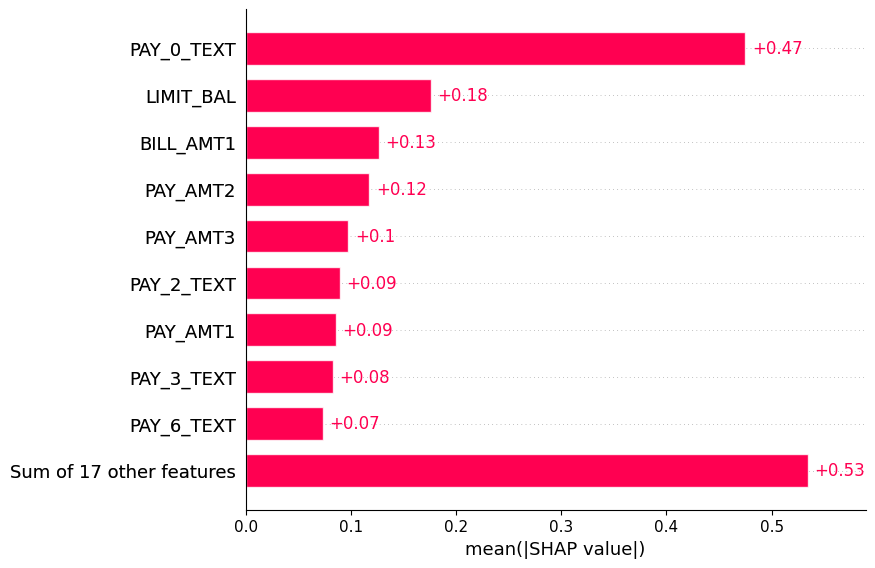

In [41]:
shap.plots.bar(shap_val_train)

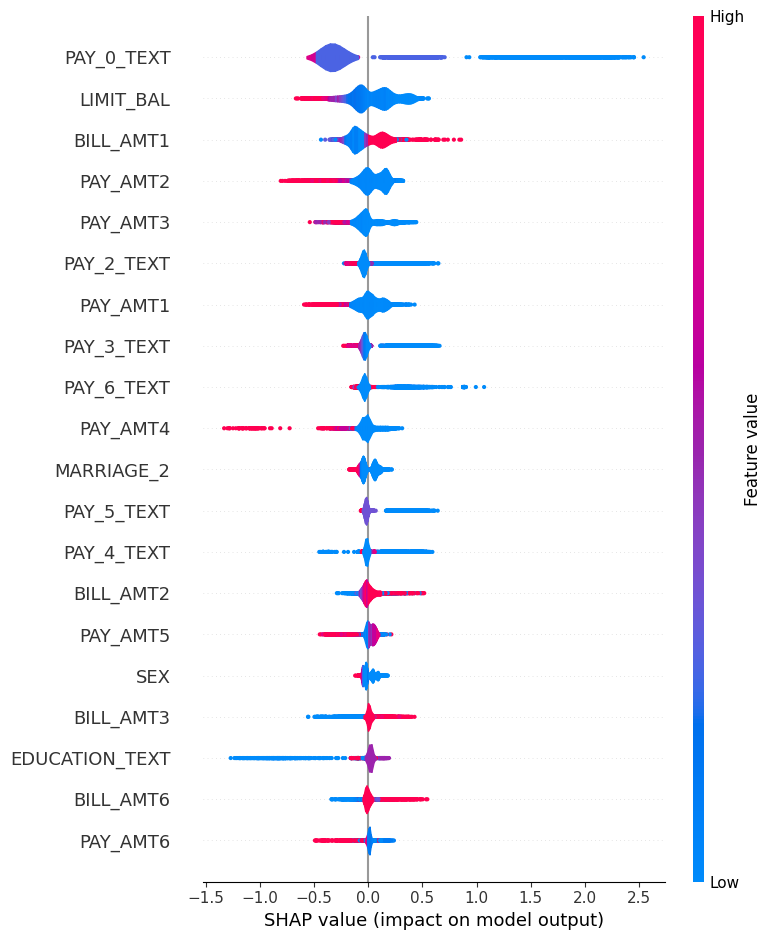

In [42]:
shap.summary_plot(shap_val_train, X_train_processed, plot_type = 'violin')

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>

rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Evaluate on the test set**: Apply your best-performing model to the test data and report the test scores.

2. **Compare and reflect**: Compare the **test scores** with the **validation scores** from previous experiments. Discuss the consistency between them. How much do you **trust your results**? Reflect on whether you might have encountered **optimization bias**.

3. **Explain individual predictions**: Select one or two examples from your test predictions and use an interpretation method (e.g., **SHAP force plots**) to explain these individual predictions.
</div>

<div class="alert alert-warning">
    
Solution_12
    
</div>

_Points:_ 10

The test score (0.638) and the average validation score (0.639) are extremely similar, so I'm not worried about optimization bias. I think my model is reasonably trustworthy, although the state of the data makes me doubt how well it'd actually perform on a live set. I would trust it much more if I trusted the data more, since I found the data to be very untrustworthy and documented poorly. Since everything is so oddly distributed in the data, some of the explanations of the variables don't make much sense.

**Prediction 1: Default** <br>
* `PAY_0_TEXT`: Paying late by 2 months increases the likelihood to default by +1.08.
* `MARRIAGE_1`: Being single increases the likelihood to default by +0.68.
* `MARRIAGE_2`: Not being married decreases the likelihood to default by -0.57.
* `BILL_AMT1`: Having a lower bill in September increases the likelihood to default by +0.24.
* `PAY_2_TEXT`: Paying late by 2 months increases the likelihood to default by +0.23.
* `PAY_4_TEXT`: Paying on time decreases the likelihood to default by -0.10.
* `SEX`: Being male increases the likelihood to default by +0.09.
* `PAY_3_TEXT`: Paying on time decreases the likelihood to default by -0.09.
* `BILL_AMT5`: Having a higher bill in September decreases the likelihood to default by -0.08.

**Prediction 2: Not Default** <br>
* `PAY_0_TEXT`: Not using credit decreases the likelihood to default by -0.98.
* `MARRIAGE_1`: Not being single decreases the likelihood to default by -0.53.
* `MARRIAGE_2`: Being married increases the likelihood to default by +0.46.
* `BILL_AMT1`: Having a lower bill in September increases the likelihood to default by +0.26.
* `PAY_5_TEXT`: Not using credit increases the likelihood to default by +0.26.
* `PAY_4_TEXT`: Not using credit decreases the likelihood to default by -0.23.
* `PAY_2_TEXT`: Not using credit decreases the likelihood to default by -0.19.
* `PAY_3_TEXT`: Not using credit decreases the likelihood to default by -0.19.
* `LIMIT_BAL`: Initially borrowing a higher amount decreases the likelihood to default by -0.16.

In [43]:
best_model = LogisticRegression(C = int(random_search_lr.best_params_['logisticregression__C']),
                                                  class_weight='balanced', max_iter=10000, random_state=123)

In [44]:
best_pipeline = make_pipeline(column_transformer, best_model)

In [45]:
best_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('minmaxscaler', ...), ('onehotencoder', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If t

In [46]:
y_predicted = best_pipeline.predict(X_test)

In [47]:
recall = recall_score(y_test, y_predicted)
print(f'The final model\'s recall is: {recall:.3f}')

The final model's recall is: 0.638


In [48]:
#Masker code from: https://stackoverflow.com/questions/66560839/what-do-maskers-really-do-in-shap-package-and-fit-them-to-train-or-test

masker = shap.maskers.Independent(data = X_train_processed)

lr_explainer = shap.LinearExplainer(best_model, masker)
shap_val_test_lr = lr_explainer(X_test_processed)

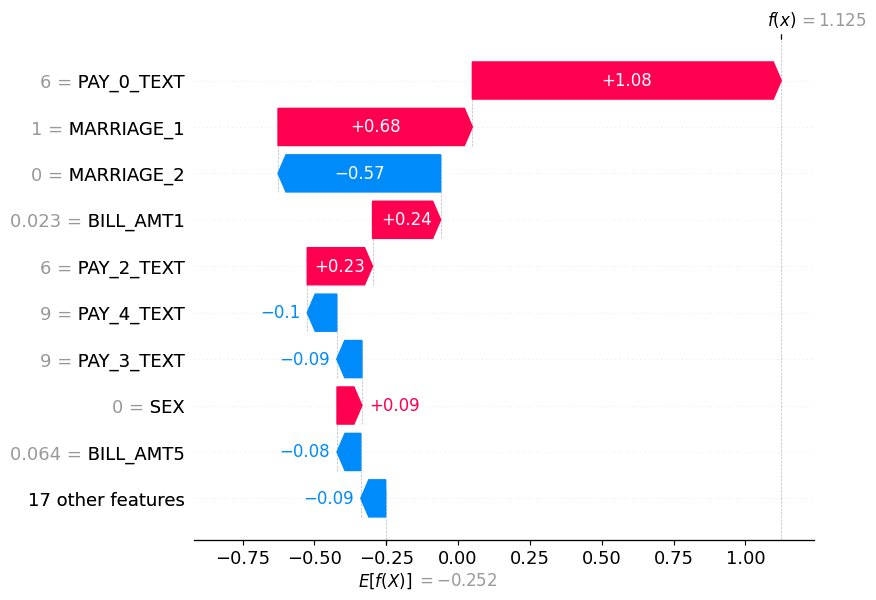

In [49]:
#Default prediction
shap.plots.waterfall(shap_val_test_lr[40])

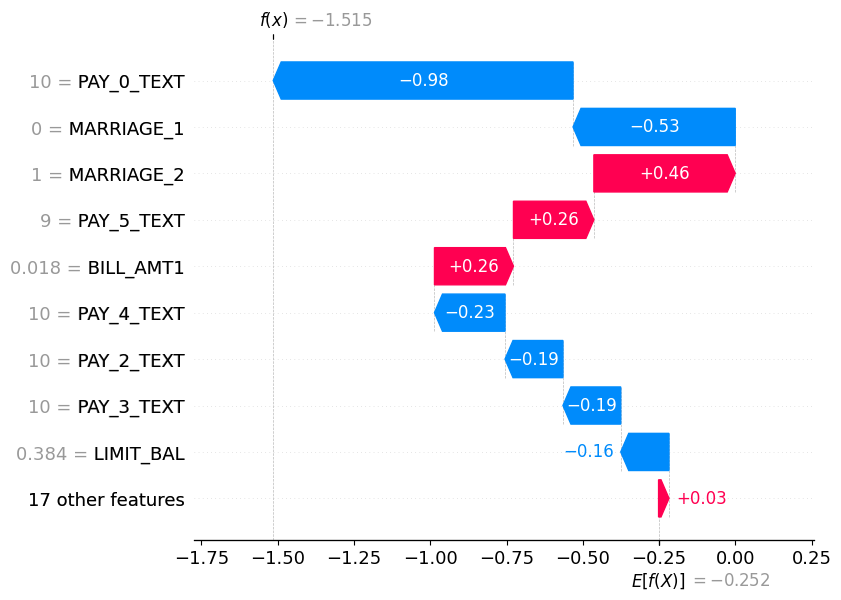

In [50]:
#Nondefault prediction
shap.plots.waterfall(shap_val_test_lr[123])

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
rubric={points:12}

Imagine you are preparing to present the summary of your results to your boss and co-workers.

<div class="alert alert-info">
    
**Your tasks:**

1. **Summarize key results**: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

2. **Write concluding remarks**: Summarize your main takeaways from the project, including what worked well and what did not.

3. **Propose future improvements**: Discuss ideas or approaches you did not try but that could potentially improve **performance** or **interpretability**.

4. **Report final results**: Report your **final test score** and the **metric** you used.

</div>


<div class="alert alert-warning">
    
Solution_13
    
</div>

_Points:_ 12

**Key Results:** <br>
The model performances are in a data frame. Here I will state my observations of the models:
| Model | Observations |
|-------|--------------|
| Logistic Regression | The best performing model. Consistently performed comfortably in the 0.60-0.65 range. Tuning was a little rough due to the nature of the cross-validation and using a random search. |
| KNN Classifier | The KNN classifier struggled the most, even after hyperparameter tuning because of the class imbalance and the outliers. While I tried to weight it by distance so that outliers and class imbalance wouldn't impact it. Clearly it didn't work as well as I'd hoped. Not having a built-in method to control class imbalance severely impacted its performance. Overfit on the training set and never really recovered despite the tuning. |
| SVM with RBF Kernel | I had to use an extremely small set to tune its hyperparameters. Otherwise, it would've run for 20 minutes without returning a result. Its training, cross-validation, and testing scores are all extremely consistent. |
| Random Forest Classifier | The random forest classifier also initially struggled, as all decision-tree based models do. After receiving tuning, it had a jump in performance that none of the other models had. Odd how it performed poorly despite not being as affected by outliers and being controlled for class imbalance. Had clear issues with overfitting that were only slightly fixed during tuning. |
| Light GBM Classifier | The heaviest model on my computer. Scored well on the training set but struggled more on the test set. Likely faced a bit of overfitting. |

**Key Takeaways:**
* Sometimes you can't get a really good (<0.7) score on your model, and that's fine. It requires a lot of domain knowledge to create the best possible model with the perfect features.
* When most of the categorical data fall under a single category, the resulting SHAP plots can be hard to make sense of.
* Documentation isn't always accurate.
* People weren't joking when they said preprocessing is 80% of the time used. Troubleshooting the column transformer took longer than I'd anticipated.

**What Worked Well:**
* Figuring out I should've set class weights for the models that had it. It resulted in a 0.2-0.3 increase in recall scores.
* Picking many light models. KNN, logistic regression, and the random forest classifier were all quick to set up, tune, and deploy.
* Fixing up some of the columns, like renaming the ordinal values. Using numbers was infinitely more of a headache than I expected so converting it to text saved me a major headache.

**What Didn't Work Well:**
* Using a wide range for the hyperparameter search. It could be a byproduct of using a randomized search method but each time I ran the tuners I frequently got a different value. They weren't too far from each other but it did get annoying having to correct my models each time.
* Trying to use 10 cross-validation fold. It nearly crashed my computer when I used it for feature searching on the LGBM model and took ages for the other larger models to run.
* Using the KNN model. I'm not sure why I picked it even though it's a model that struggles with class imbalance and outliers.

**Future Improvements:** <br>
Some future improvement I think I could take are to use a validation set and use a different method to handle the class imbalance. I didn't use a validation set this time around and while I'm not sure if it would've made any difference with the scoring, considering how little every other method improved the recall, I still wonder if it could've had a greater impact on improving my models. Another thing I would've liked to do is try different sampling methods to control for my class imbalance. The most common method suggested is using SMOTE. I'm not familiar with the method, but I'd like to think it could've improved my performance far more than hyperparameter tuning, feature selection, and feature engineering combined. 

In [51]:
print(f'The final model\'s recall is: {recall:.3f}')

The final model's recall is: 0.638


In [52]:
new_knn = KNeighborsClassifier(n_neighbors = 3, weights = 'distance')
new_svm = SVC(C = 100, gamma = 0.01, random_state = 123, kernel = 'rbf', class_weight = 'balanced')
new_random_forest = RandomForestClassifier(n_estimators = 160, max_depth = 10,
                                           random_state = 123, n_jobs = -1, class_weight = 'balanced')
new_lgbm = LGBMClassifier(num_leaves = 12, max_depth = 40, random_state = 123,
                          n_jobs = -1, verbosity = -1, class_weight = 'balanced')

new_models = [new_knn, new_svm, new_random_forest, new_lgbm]
test_values = []
for new_model in new_models:
    new_pipe_new_model = make_pipeline(column_transformer, new_model)
    new_pipe_new_model.fit(X_train, y_train)
    new_y_pred = new_pipe_new_model.predict(X_test)
    test_values.append(round(recall_score(y_test, new_y_pred), 3))

In [53]:
model_index = ['Dummy Classifier', 'Logistic Regression', 'KNN Classifier',
               'SVMRBF', 'Random Forest Classifier', 'Light GBM Classifier']
cv_values = [0.000, 0.639, 0.380, 0.572, 0.554, 0.635]
final_test_values = [np.nan, 0.638] + test_values
pd.DataFrame(data = {'Average Cross-Validation Recall': cv_values,
                    'Test Recall': final_test_values},
            index = model_index)

,Average Cross-Validation Recall,Test Recall
Dummy Classifier,0.000,NaN
Logistic Regression,0.639,0.638
KNN Classifier,0.380,0.373
SVMRBF,0.572,0.573
Random Forest Classifier,0.554,0.559
Light GBM Classifier,0.635,0.629


<!-- END QUESTION -->

<br><br>

<br><br>

<!-- BEGIN QUESTION -->

## 14. Your takeaway
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  

</div>

<div class="alert alert-warning">
    
Solution_14
    
</div>

_Points:_ 2

My biggest takeaway from the material is how much the actual process deviates from what I'm used to seeing on the homework. Usually on the other homework it's a straightforward process from point A to point B, but doing a mini project makes me tune hyperparameters, see that all my scores are still low, then go back to fix the weighting in the models, then change the hyperparameters in the model, etc. It's a very complicated process and I see how most people say it's the preprocessing and feature engineering that takes the most time because I didn't expect *everything* to hinge on how I processed my data. If I wasn't happy with a model's performance (and after tweaking the model's hyperparameters), I would always return to the EDA to see if I could glean any information from the graphs for the feature engineering. Then after doing the feature engineering the best hyperparameters and recall scores would inevitably change and I'd have to go fix something somewhere else.

It's a very involved process that I think most of the homework doesn't really show.

<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please ensure you have followed all the steps in the **Instructions** section at the top.  

### Submission checklist  

- [ ] Restart the kernel and run all cells (▶▶ button)
- [ ] Make sure to push the most up to date version of your homework assignment to your GitHub repository so that we can use it for grading if there are any problems with your submission on Gradescope. 
- [ ] The `.ipynb` file runs without errors and shows all outputs.  
- [ ] Only the `.ipynb` file and required output files are uploaded (no extra files).  
- [ ] If the `.ipynb` file is too large to render on Gradescope, upload a Web PDF and/or HTML version as well.


This was a tricky one but you did it 👏👏!  

![](img/eva-well-done.png)